In [24]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation

In [27]:
def get_results_imgs(simulation, iterations=50,  type1 = 'giving', type2 = 'attacking', type3 = 'random', save_dir=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)
        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = ''
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'Type 1 : {type1}'),
        Patch(facecolor='blue', edgecolor='b', label=f'Type 2 : {type2}'),
        Patch(facecolor='green', edgecolor='g', label=f'Type 3 : {type3}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final population distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'final_population_distribution.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'Population 1 : {type1}', color='red')
    plt.plot(np.arange(iterations), pop2_size, '--', label=f'Population 2 : {type2}', color='blue')
    plt.plot(np.arange(iterations), pop3_size, label=f'Population 3 : {type3}', color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'population_size_over_time.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 35.5163459777832
Population 2: attacking - 39.240203857421875
Population 3: random - 21.991439819335938

Total fitness: 96.74798583984375

Final population %'s fitness:
Population 1: attacking - 36.71%
Population 2: attacking - 40.56%
Population 3: random - 22.73%



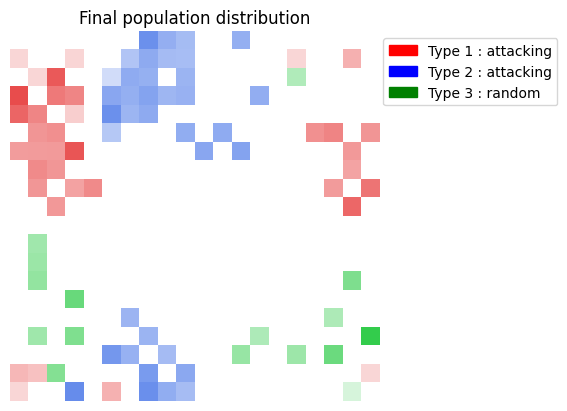

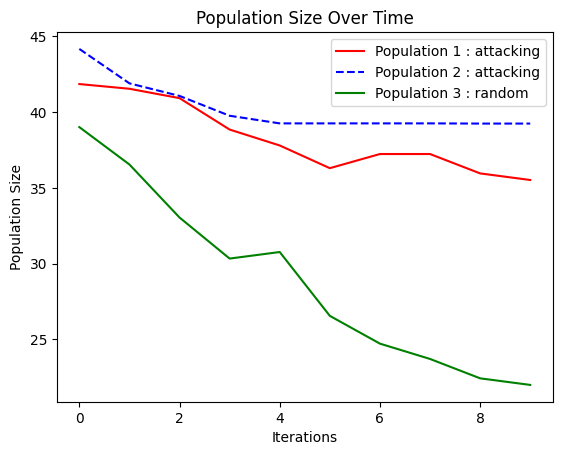

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 33.92577362060547
Population 2: attacking - 48.516700744628906
Population 3: random - 32.48933029174805

Total fitness: 114.93180847167969

Final population %'s fitness:
Population 1: giving - 29.52%
Population 2: attacking - 42.21%
Population 3: random - 28.27%



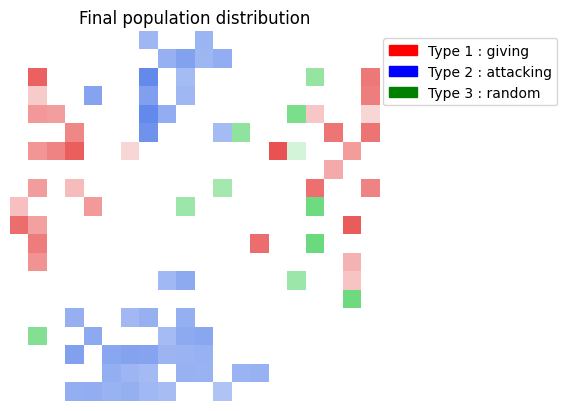

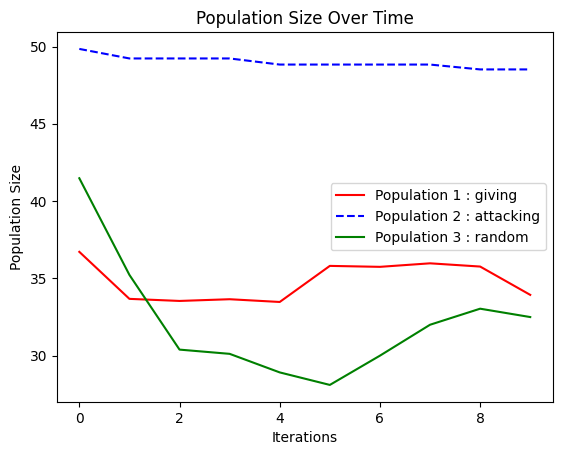

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 41.46127700805664
Population 2: attacking - 27.34576416015625
Population 3: random - 27.865909576416016

Total fitness: 96.67294311523438

Final population %'s fitness:
Population 1: complete - 42.89%
Population 2: attacking - 28.29%
Population 3: random - 28.82%



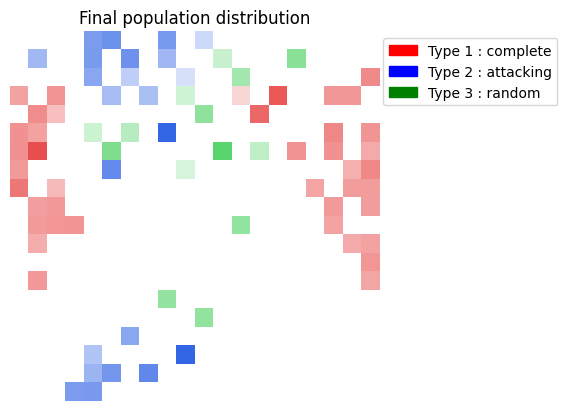

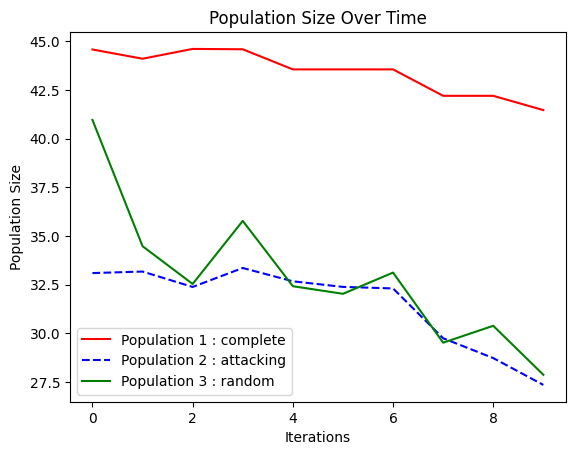

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 42.26903533935547
Population 2: giving - 23.774023056030273
Population 3: attacking - 33.09453582763672

Total fitness: 99.1375961303711

Final population %'s fitness:
Population 1: complete - 42.64%
Population 2: giving - 23.98%
Population 3: attacking - 33.38%



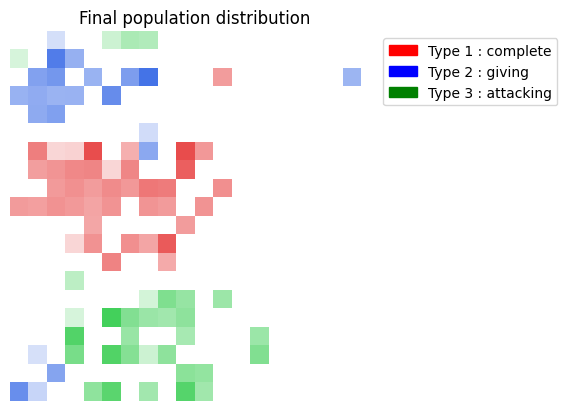

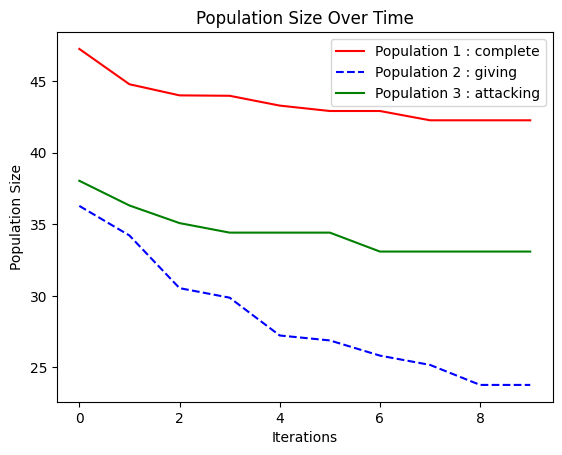

Creating simulation with parameters: bonus_0_1 - fitness_donation: 0.0 - fitness_growth: 0.1
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 29.967546463012695
Population 2: attacking - 23.06574249267578
Population 3: random - 29.58586883544922

Total fitness: 82.61915588378906

Final population %'s fitness:
Population 1: attacking - 36.27%
Population 2: attacking - 27.92%
Population 3: random - 35.81%



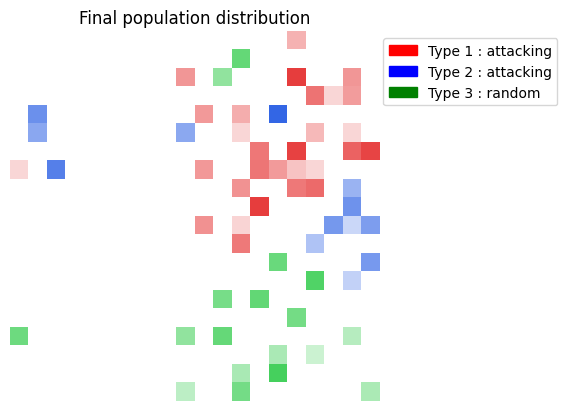

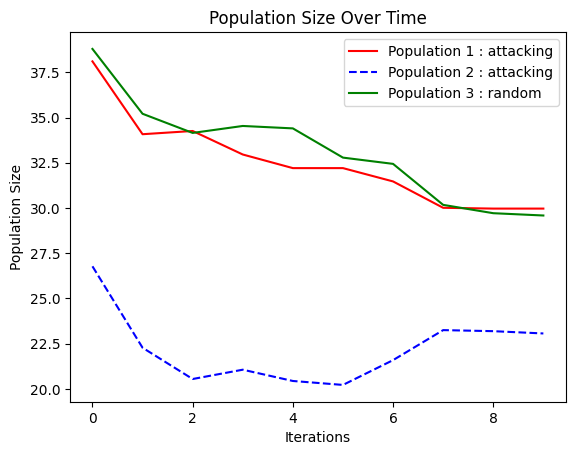

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 43.53013610839844
Population 2: attacking - 45.054405212402344
Population 3: random - 18.91614532470703

Total fitness: 107.50068664550781

Final population %'s fitness:
Population 1: giving - 40.49%
Population 2: attacking - 41.91%
Population 3: random - 17.60%



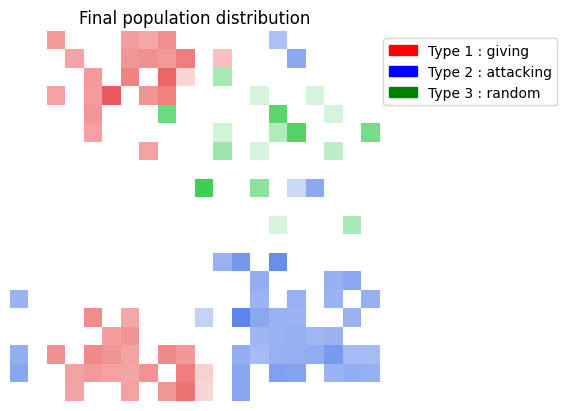

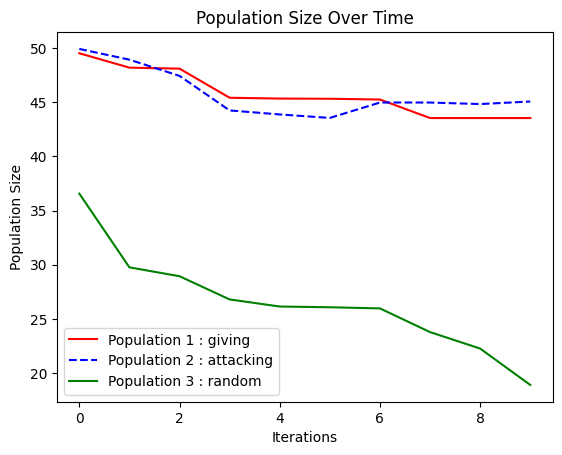

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 50.18892288208008
Population 2: attacking - 38.67680740356445
Population 3: random - 29.81003189086914

Total fitness: 118.67576599121094

Final population %'s fitness:
Population 1: complete - 42.29%
Population 2: attacking - 32.59%
Population 3: random - 25.12%



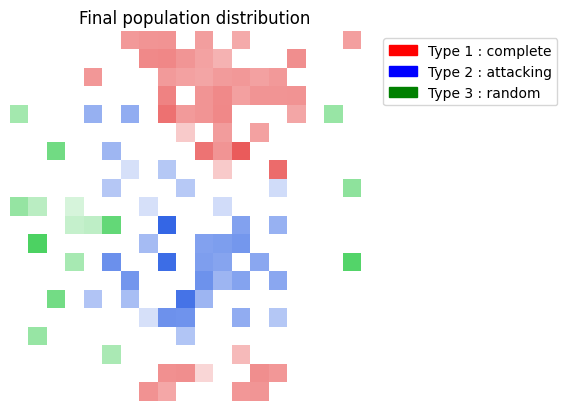

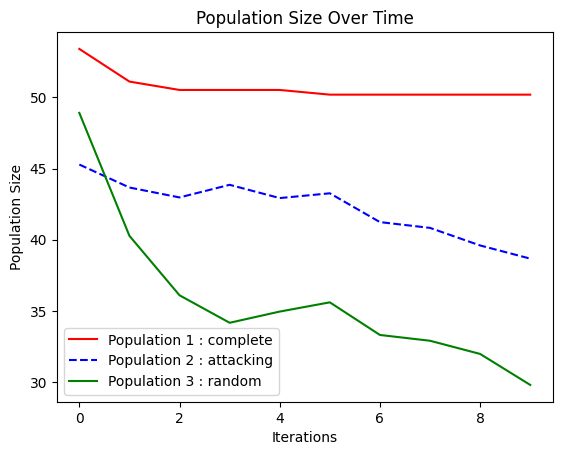

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 31.39956283569336
Population 2: giving - 27.300518035888672
Population 3: attacking - 49.57150650024414

Total fitness: 108.27159118652344

Final population %'s fitness:
Population 1: complete - 29.00%
Population 2: giving - 25.21%
Population 3: attacking - 45.78%



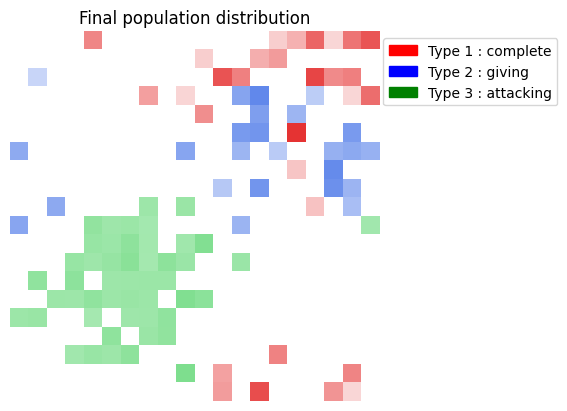

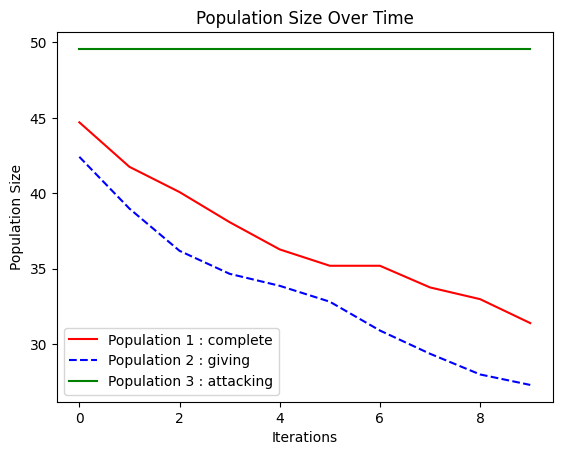

Creating simulation with parameters: bonus_1_0 - fitness_donation: 0.1 - fitness_growth: 0.0
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 50.734432220458984
Population 2: attacking - 53.47792053222656
Population 3: random - 26.466033935546875

Total fitness: 130.6783905029297

Final population %'s fitness:
Population 1: attacking - 38.82%
Population 2: attacking - 40.92%
Population 3: random - 20.25%



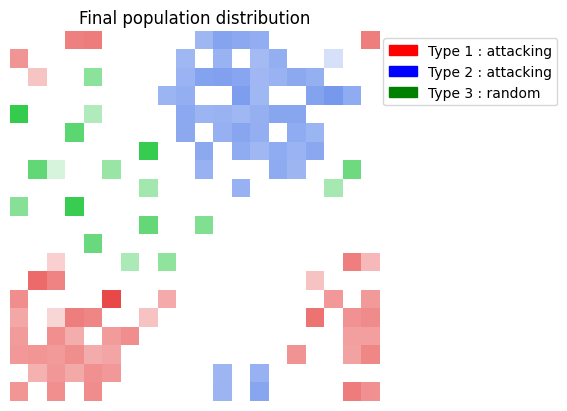

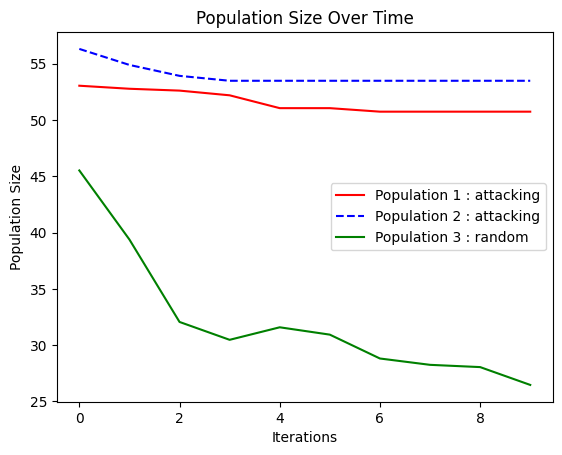

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 39.89379119873047
Population 2: attacking - 36.0791130065918
Population 3: random - 26.15865707397461

Total fitness: 102.13156127929688

Final population %'s fitness:
Population 1: giving - 39.06%
Population 2: attacking - 35.33%
Population 3: random - 25.61%



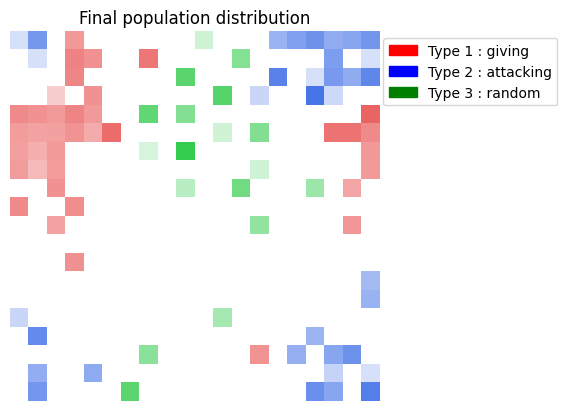

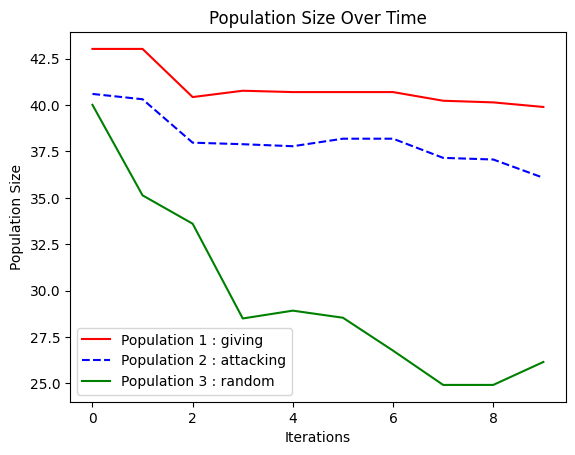

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 31.045948028564453
Population 2: attacking - 48.21957778930664
Population 3: random - 28.020475387573242

Total fitness: 107.28600311279297

Final population %'s fitness:
Population 1: complete - 28.94%
Population 2: attacking - 44.94%
Population 3: random - 26.12%



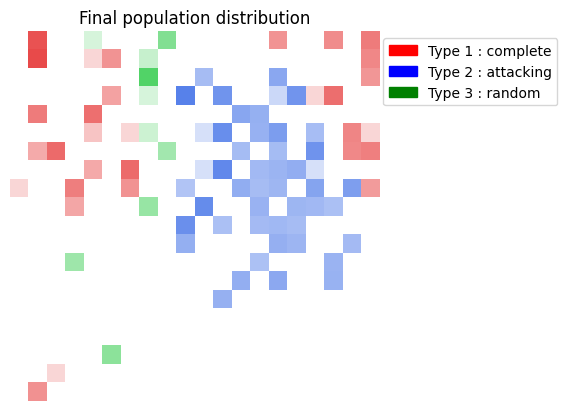

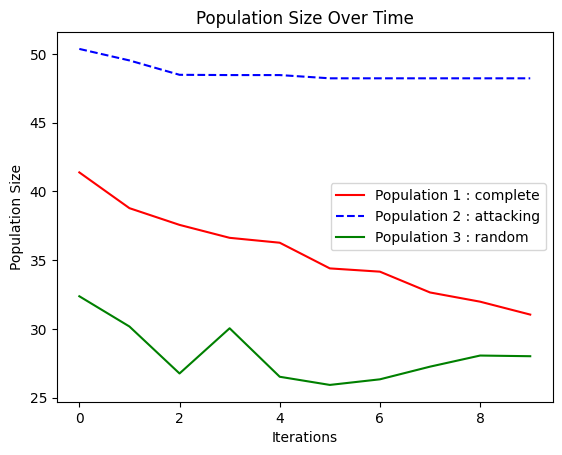

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 32.22160339355469
Population 2: giving - 50.31429672241211
Population 3: attacking - 39.28340148925781

Total fitness: 121.81930541992188

Final population %'s fitness:
Population 1: complete - 26.45%
Population 2: giving - 41.30%
Population 3: attacking - 32.25%



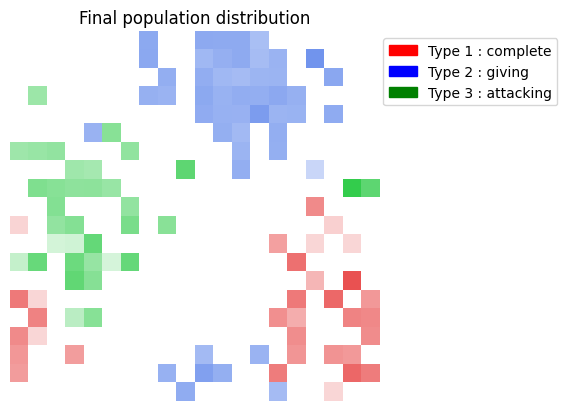

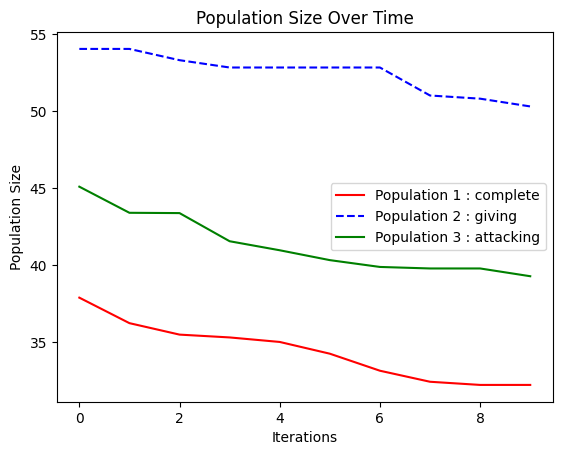

Creating simulation with parameters: bonus_1_1 - fitness_donation: 0.1 - fitness_growth: 0.1
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 38.26106643676758
Population 2: attacking - 34.28462600708008
Population 3: random - 24.041019439697266

Total fitness: 96.58671569824219

Final population %'s fitness:
Population 1: attacking - 39.61%
Population 2: attacking - 35.50%
Population 3: random - 24.89%



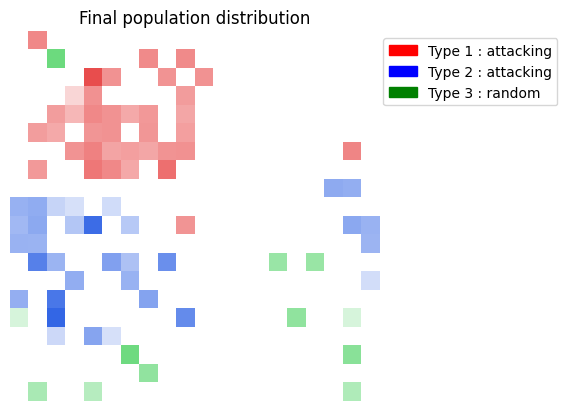

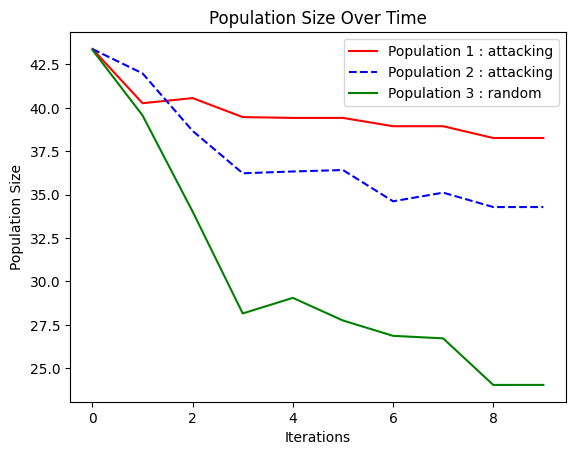

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 44.585609436035156
Population 2: attacking - 39.62788772583008
Population 3: random - 33.6559944152832

Total fitness: 117.86949157714844

Final population %'s fitness:
Population 1: giving - 37.83%
Population 2: attacking - 33.62%
Population 3: random - 28.55%



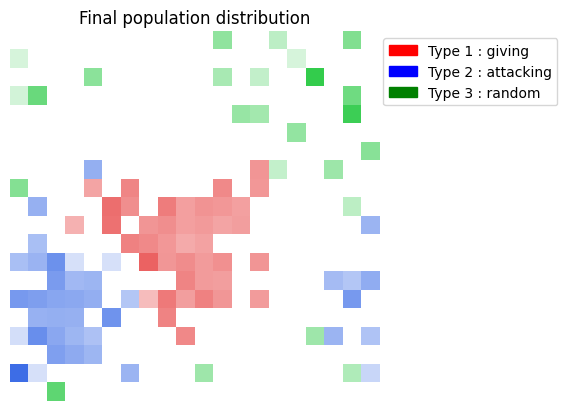

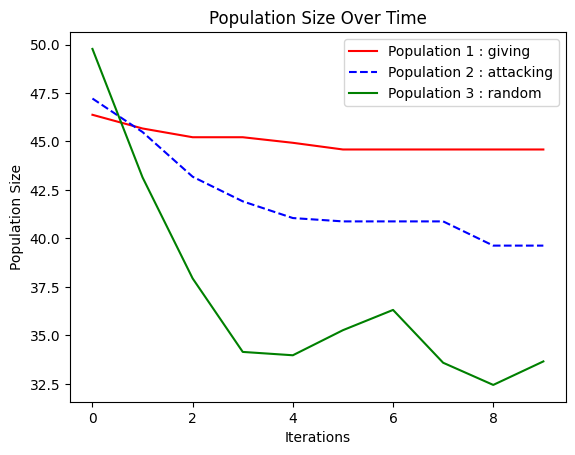

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 31.090578079223633
Population 2: attacking - 47.80270767211914
Population 3: random - 27.379650115966797

Total fitness: 106.27293395996094

Final population %'s fitness:
Population 1: complete - 29.26%
Population 2: attacking - 44.98%
Population 3: random - 25.76%



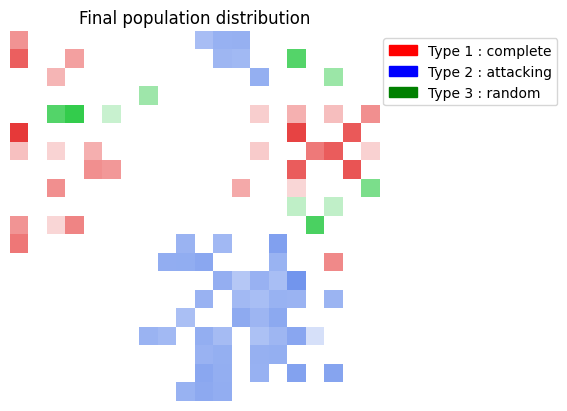

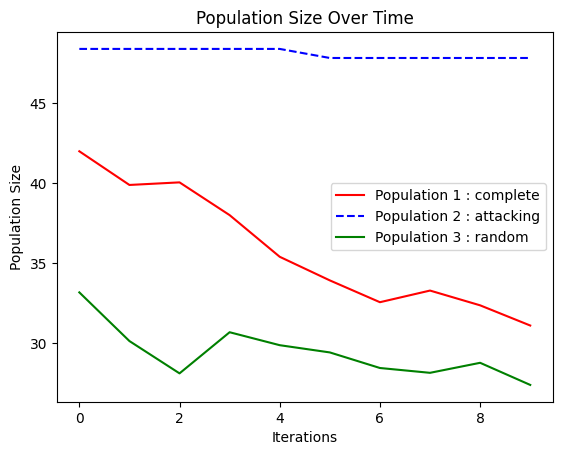

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 42.996089935302734
Population 2: giving - 42.210453033447266
Population 3: attacking - 37.102020263671875

Total fitness: 122.30856323242188

Final population %'s fitness:
Population 1: complete - 35.15%
Population 2: giving - 34.51%
Population 3: attacking - 30.33%



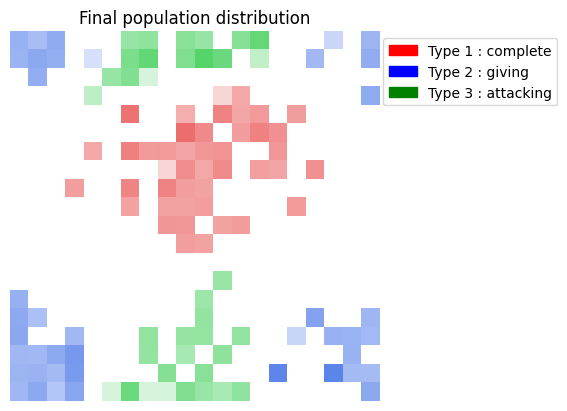

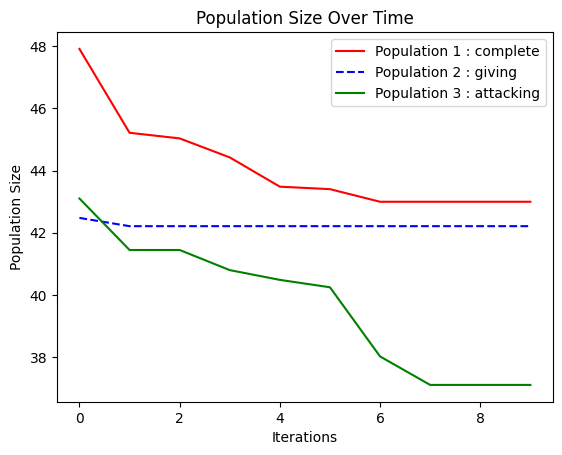

Creating simulation with parameters: bonus_2_0 - fitness_donation: 0.2 - fitness_growth: 0.0
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 45.29665756225586
Population 2: attacking - 46.869815826416016
Population 3: random - 22.605863571166992

Total fitness: 114.7723388671875

Final population %'s fitness:
Population 1: attacking - 39.47%
Population 2: attacking - 40.84%
Population 3: random - 19.70%



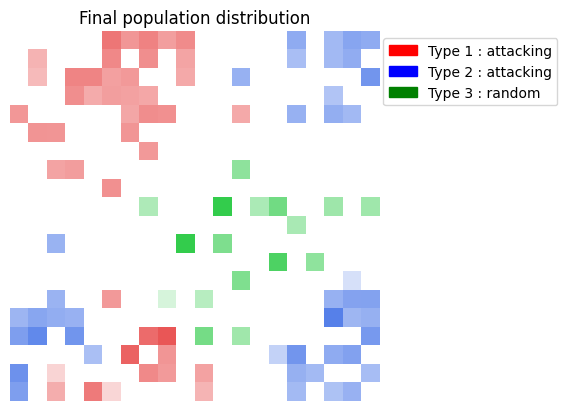

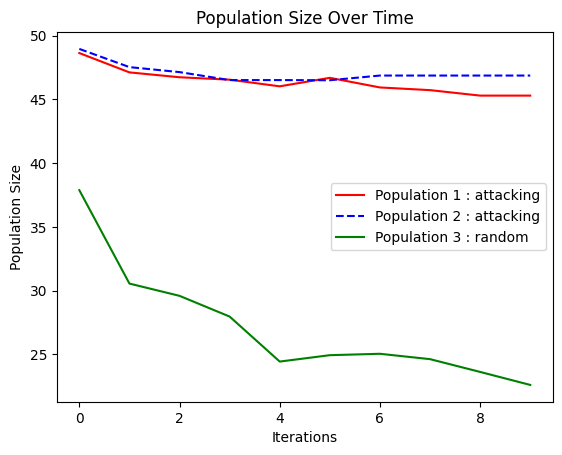

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 25.680866241455078
Population 2: attacking - 17.066179275512695
Population 3: random - 21.32929229736328

Total fitness: 64.07633972167969

Final population %'s fitness:
Population 1: giving - 40.08%
Population 2: attacking - 26.63%
Population 3: random - 33.29%



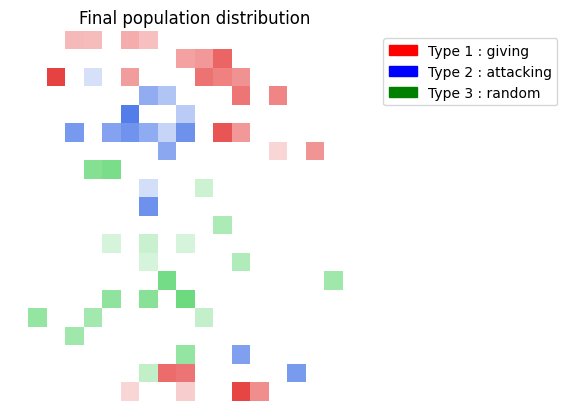

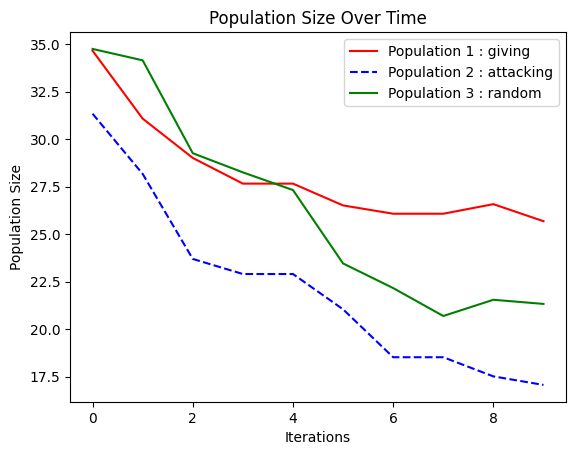

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 45.564208984375
Population 2: attacking - 46.956485748291016
Population 3: random - 25.69830894470215

Total fitness: 118.21900177001953

Final population %'s fitness:
Population 1: complete - 38.54%
Population 2: attacking - 39.72%
Population 3: random - 21.74%



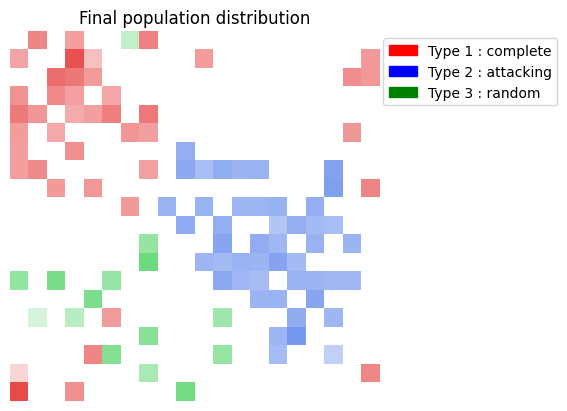

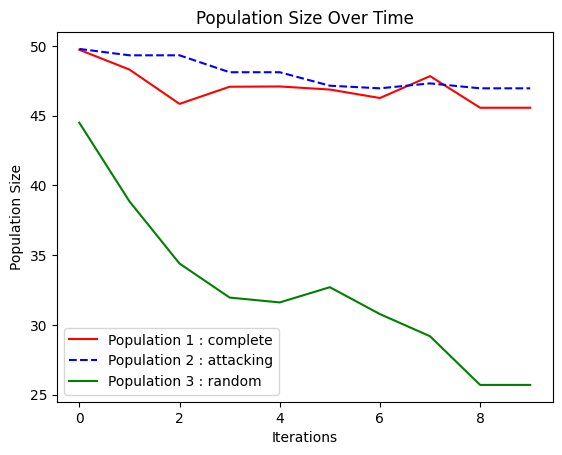

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 34.24391555786133
Population 2: giving - 50.61400604248047
Population 3: attacking - 41.54356384277344

Total fitness: 126.4014892578125

Final population %'s fitness:
Population 1: complete - 27.09%
Population 2: giving - 40.04%
Population 3: attacking - 32.87%



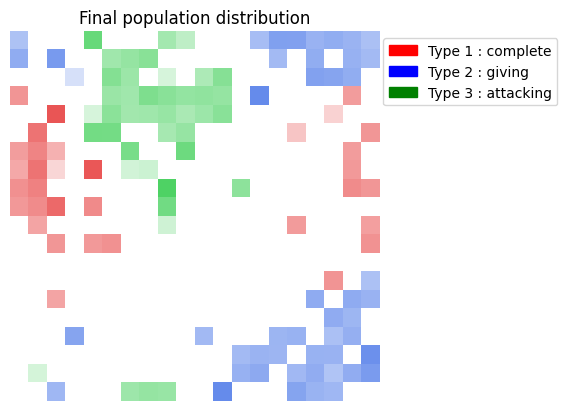

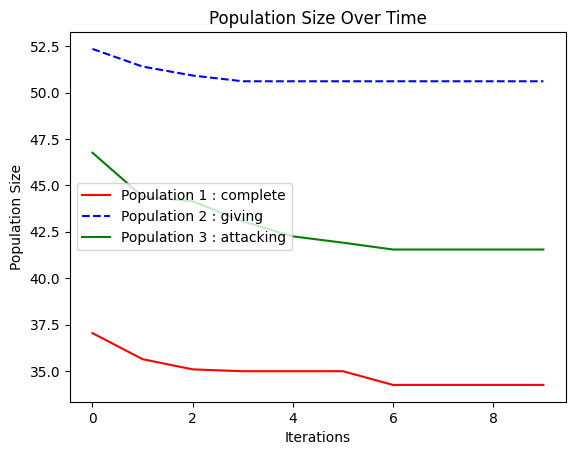

Creating simulation with parameters: bonus_2_1 - fitness_donation: 0.0 - fitness_growth: 0.2
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 44.81257629394531
Population 2: attacking - 44.862003326416016
Population 3: random - 19.84941864013672

Total fitness: 109.52399444580078

Final population %'s fitness:
Population 1: attacking - 40.92%
Population 2: attacking - 40.96%
Population 3: random - 18.12%



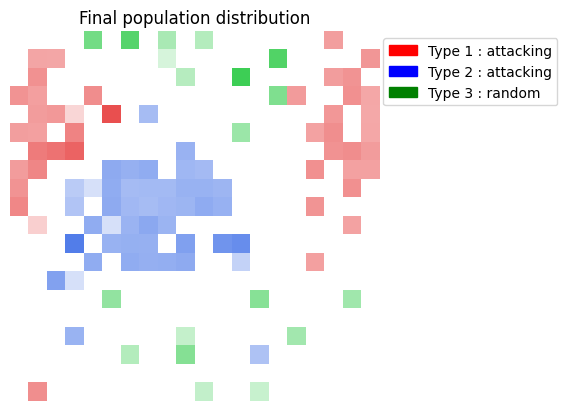

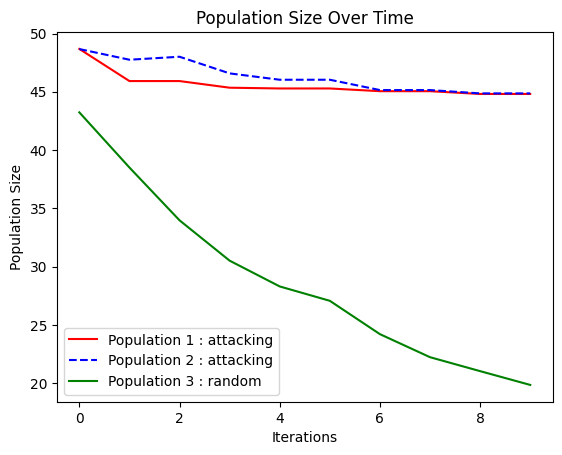

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 44.53168487548828
Population 2: attacking - 41.87982940673828
Population 3: random - 29.342294692993164

Total fitness: 115.7538070678711

Final population %'s fitness:
Population 1: giving - 38.47%
Population 2: attacking - 36.18%
Population 3: random - 25.35%



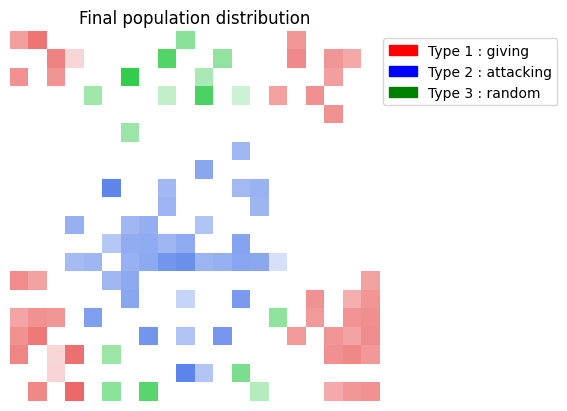

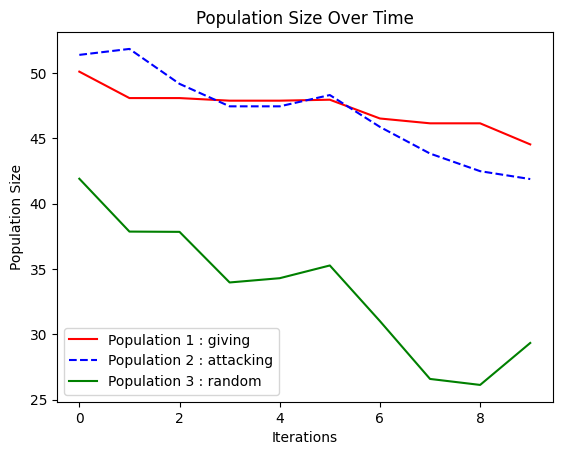

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 51.522552490234375
Population 2: attacking - 47.72371292114258
Population 3: random - 24.6983699798584

Total fitness: 123.94463348388672

Final population %'s fitness:
Population 1: complete - 41.57%
Population 2: attacking - 38.50%
Population 3: random - 19.93%



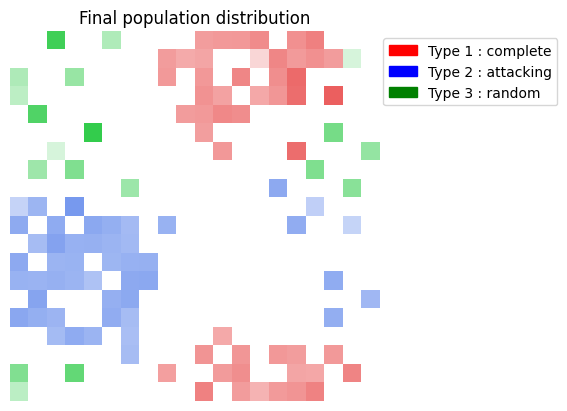

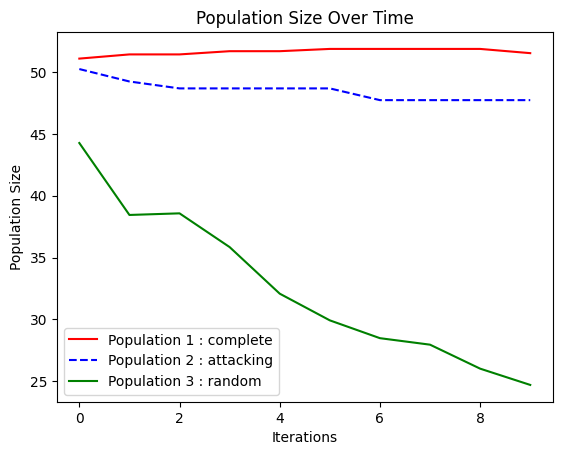

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 45.79789733886719
Population 2: giving - 34.62571716308594
Population 3: attacking - 35.95415496826172

Total fitness: 116.37776947021484

Final population %'s fitness:
Population 1: complete - 39.35%
Population 2: giving - 29.75%
Population 3: attacking - 30.89%



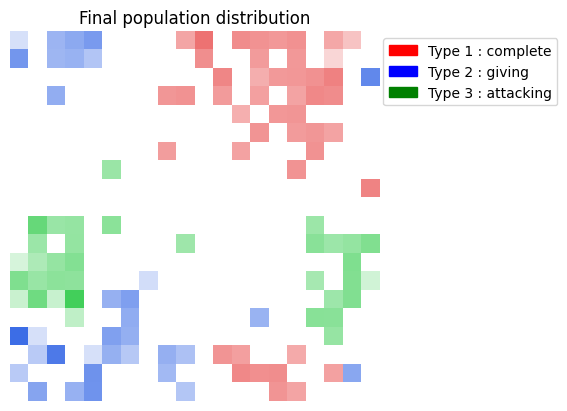

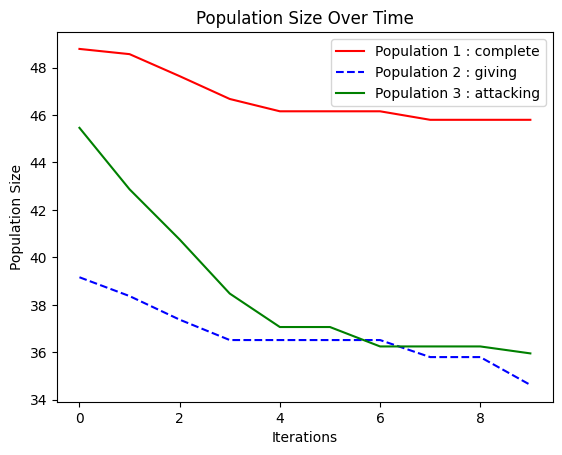

Creating simulation with parameters: bonus_2_2 - fitness_donation: 0.2 - fitness_growth: 0.2
Creating simulation: attack vs random
Final population fitness:
Population 1: attacking - 46.73320007324219
Population 2: attacking - 24.514461517333984
Population 3: random - 22.27370834350586

Total fitness: 93.52137756347656

Final population %'s fitness:
Population 1: attacking - 49.97%
Population 2: attacking - 26.21%
Population 3: random - 23.82%



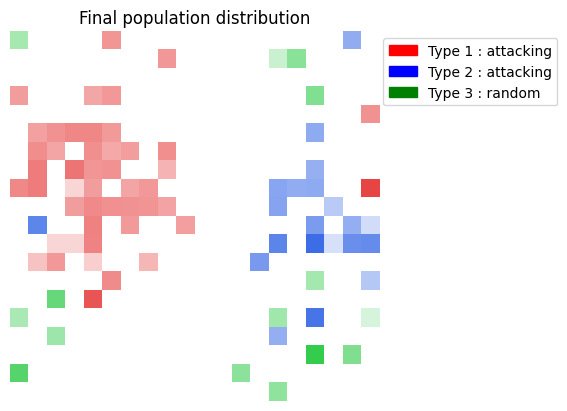

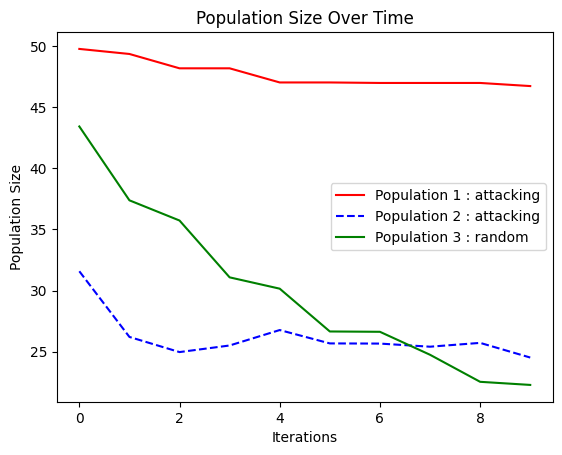

Creating simulation: giving vs random
Final population fitness:
Population 1: giving - 51.33937072753906
Population 2: attacking - 49.27945327758789
Population 3: random - 26.838397979736328

Total fitness: 127.45721435546875

Final population %'s fitness:
Population 1: giving - 40.28%
Population 2: attacking - 38.66%
Population 3: random - 21.06%



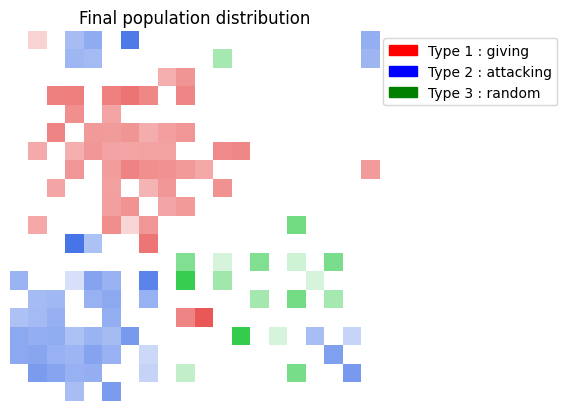

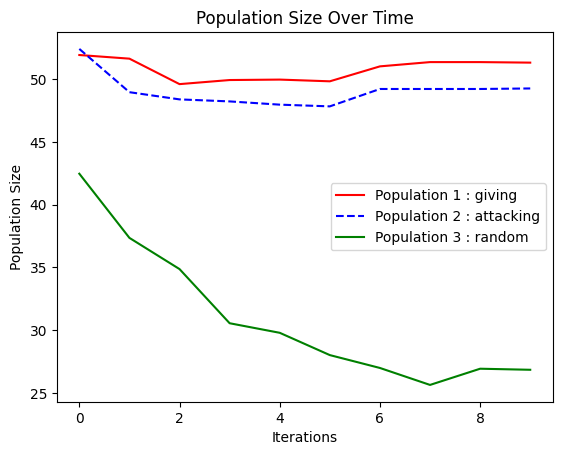

Creating simulation: complete vs random
Final population fitness:
Population 1: complete - 29.917314529418945
Population 2: attacking - 25.710248947143555
Population 3: random - 27.610843658447266

Total fitness: 83.2384033203125

Final population %'s fitness:
Population 1: complete - 35.94%
Population 2: attacking - 30.89%
Population 3: random - 33.17%



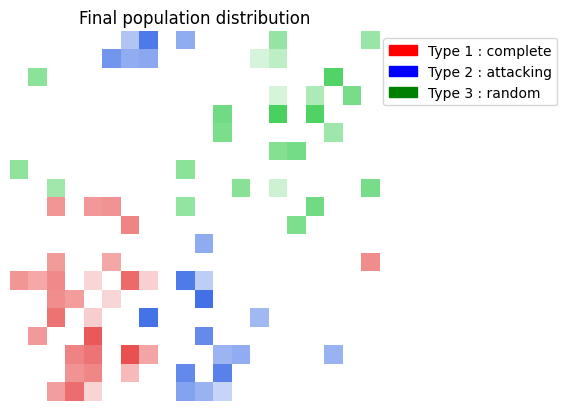

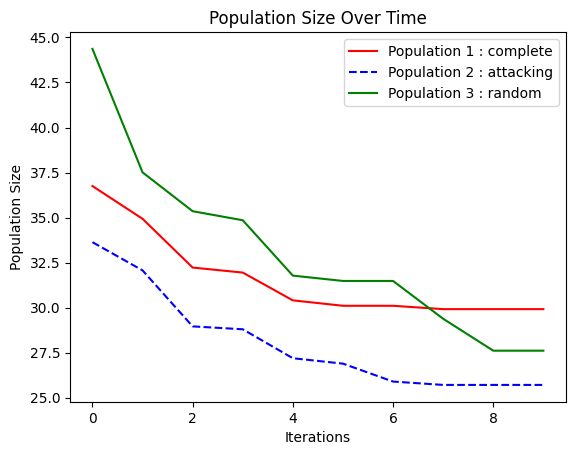

Creating simulation: complete vs giving vs attacking
Final population fitness:
Population 1: complete - 38.4516716003418
Population 2: giving - 39.371952056884766
Population 3: attacking - 47.68901443481445

Total fitness: 125.51263427734375

Final population %'s fitness:
Population 1: complete - 30.64%
Population 2: giving - 31.37%
Population 3: attacking - 38.00%



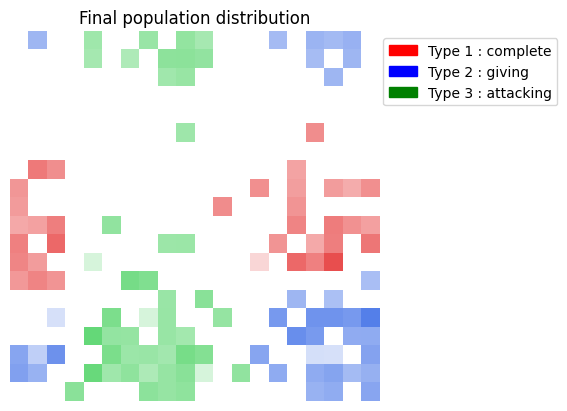

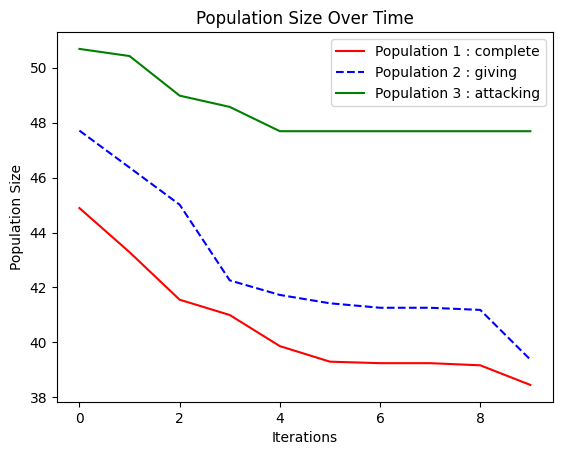

In [28]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_1', 0.0, 0.1), ('bonus_1_0', 0.1, 0.0), ('bonus_1_1', 0.1, 0.1), ('bonus_2_0', 0.2, 0.0), ('bonus_2_1', 0.0, 0.2), ('bonus_2_2', 0.2, 0.2)]

all_results_string = 'Popultion 1 total fitness; Popultion 2 total fitness; Popultion 2 total fitness; Popultion 1 \% fitness; Popultion 2 \% fitness; Popultion 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 10

# Simulation parameters
nb_batches = 1
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking')

    if SAVE_DIR is not None:
        results_string = f"Simulation: {sub_dir_name} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {sub_dir_name} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {sub_dir_name} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {sub_dir_name} - complete vs giving vs attacking\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)
